In [8]:
import os
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skimage.feature import hog


# Transfer learning approach: extract HOG (Histogram of Oriented Gradients) features
# which capture edge/texture information, then train a lightweight classifier

In [9]:
healthy_classes = [
    "Apple", "Avocado", "Banana", "Beef", "Beef-Fillet", "Beef-Goulash", "Beef-Patty",
    "Blueberry-Yogurt", "Grapes", "Grilled-Chicken-Salad", "Grilled-Pizza", "Ground-Beef",
    "Honey", "Jackfruit", "Kiwi", "Lemon", "Lime", "Lychees", "Mango", "Milk", "Mint",
    "Mozzarella", "Orange", "Pancake", "Papaya", "Parsley", "Passion-Fruit", "Peach",
    "Pear", "Pineapple", "Plum", "Raspberries", "Sandwich", "Strawberries", "Tangerine",
    "Watermelon", "Yogurt", "American-Cheese"
]

unhealthy_classes = [
    "BBQ-Chicken-Pizza", "BBQ-Pizza", "Beef-Pizza", "Beef-Ribs", "Beef-Steak", "Biscuit",
    "Cheese-Pizza", "Chicken-Pizza", "Cupcake", "Donut", "Double-Cheeseburger", "Egg-Roll",
    "Hot-Chocoloate", "Hot-Dog", "Mayonnaise", "Muffin", "Mustard", "Pie", "Sausage-Pizza",
    "Seafood-Pizza", "Vanilla-Yogurt", "Vegetable-Pizza", "Vegetarian-Pizza", "Waffles",
    "Zinger-Burger", "Chocolate-Yogurt", "Strawberry-Jam"
]

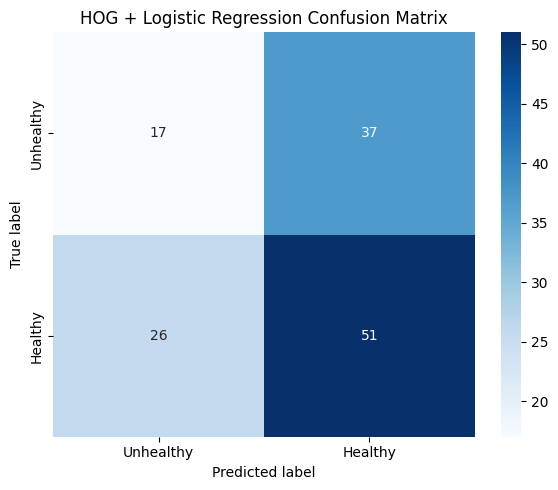

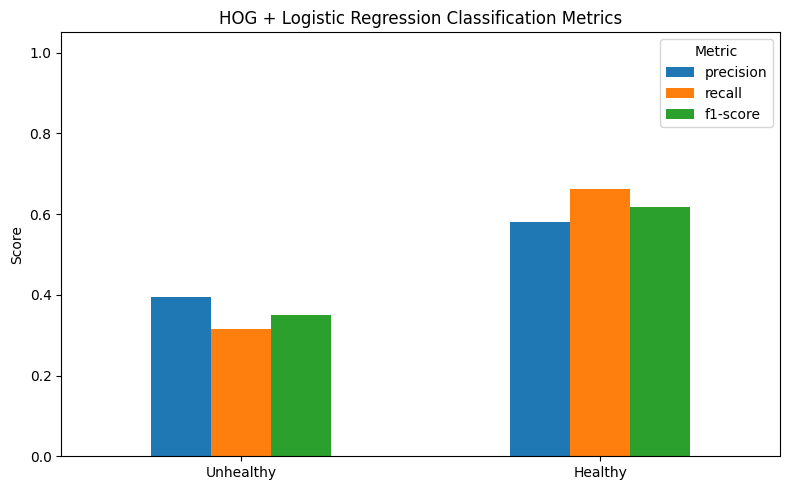

Saved evaluation files to: c:\Users\stangutur\DS-4002-Group4Project3\OUTPUT
Saved files:
 - hog_confusion_matrix.csv
 - hog_classification_report.csv
 - hog_evaluation_summary.csv
 - hog_confusion_matrix.png
 - hog_classification_metrics.png


In [10]:
# Save all evaluation tables and visualizations to OUTPUT
repo_root = os.path.abspath(os.path.join(train_dir, os.pardir, os.pardir, os.pardir, os.pardir))
output_dir = os.path.join(repo_root, "OUTPUT")
os.makedirs(output_dir, exist_ok=True)

class_names = ["Unhealthy", "Healthy"]
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
summary_df = pd.DataFrame({
    "accuracy": [accuracy],
    "test_samples": [int(y_test.shape[0])]
})

cm_df.to_csv(os.path.join(output_dir, "hog_confusion_matrix.csv"), index=True)
report_df.to_csv(os.path.join(output_dir, "hog_classification_report.csv"), index=True)
summary_df.to_csv(os.path.join(output_dir, "hog_evaluation_summary.csv"), index=False)

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("HOG + Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hog_confusion_matrix.png"))
plt.show()

# Classification metrics bar chart
metrics_df = report_df.loc[class_names, ["precision", "recall", "f1-score"]]
fig, ax = plt.subplots(figsize=(8, 5))
metrics_df.plot(kind="bar", ax=ax)
ax.set_title("HOG + Logistic Regression Classification Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(class_names, rotation=0)
ax.legend(title="Metric")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hog_classification_metrics.png"))
plt.show()

print(f"Saved evaluation files to: {output_dir}")
print("Saved files:\n - hog_confusion_matrix.csv\n - hog_classification_report.csv\n - hog_evaluation_summary.csv\n - hog_confusion_matrix.png\n - hog_classification_metrics.png")

In [4]:
# ---------------------------------------------------------
# 4. TRANSFER LEARNING FEATURE EXTRACTION (HOG)
# ---------------------------------------------------------
# Using HOG (Histogram of Oriented Gradients): robust, effective features for image classification


In [5]:
# ---------------------------------------------------------
# 3. TRAIN/TEST SPLIT
# ---------------------------------------------------------

print("Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Splitting data into train and test sets...
Training set size: 522
Test set size: 131


Extracting HOG features from training set...
Training HOG features shape: (522, 26244)
Extracting HOG features from test set...
Test HOG features shape: (131, 26244)
Training Logistic Regression on HOG features...
Model training completed!
=== TRANSFER LEARNING RESULTS (HOG + Logistic Regression) ===
Accuracy: 0.5190839694656488

Confusion Matrix:
 [[17 37]
 [26 51]]

Classification Report:
               precision    recall  f1-score   support

   Unhealthy       0.40      0.31      0.35        54
     Healthy       0.58      0.66      0.62        77

    accuracy                           0.52       131
   macro avg       0.49      0.49      0.48       131
weighted avg       0.50      0.52      0.51       131



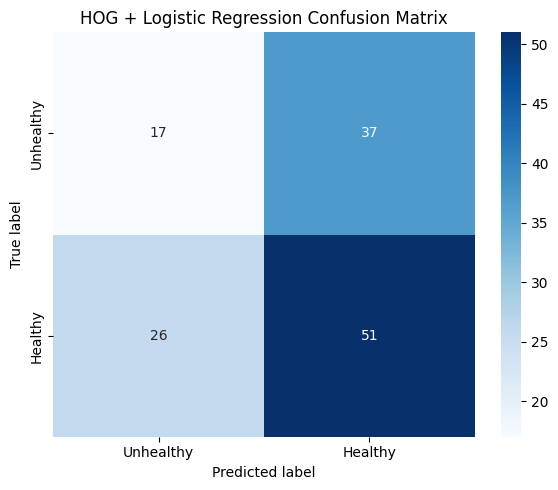

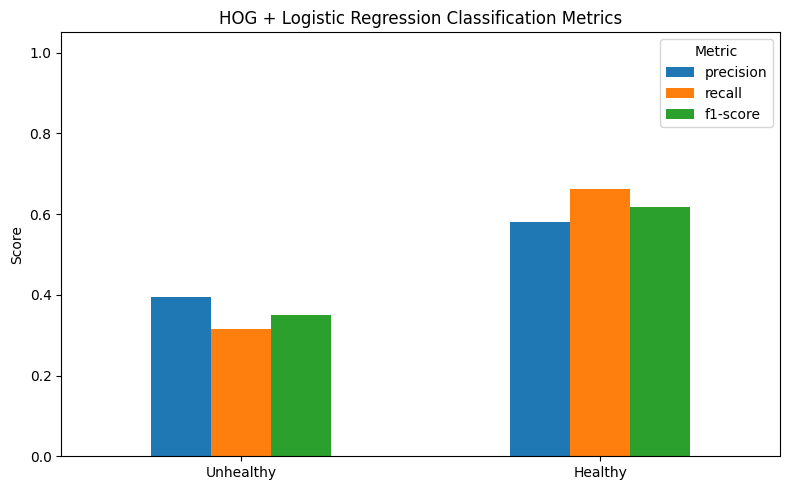

Saved evaluation files to: c:\Users\stangutur\DS-4002-Group4Project3\DATA\OUTPUT
Saved files:
 - hog_confusion_matrix.csv
 - hog_classification_report.csv
 - hog_evaluation_summary.csv
 - hog_confusion_matrix.png
 - hog_classification_metrics.png


In [7]:
# ---------------------------------------------------------
# 5. EXTRACT HOG FEATURES AND TRAIN CLASSIFIER
# ---------------------------------------------------------
def extract_hog_features(images):
    """Extract HOG (Histogram of Oriented Gradients) features."""
    features = []
    for img in images:
        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        # Extract HOG features
        hog_features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), visualize=False)
        features.append(hog_features)
    return np.array(features)

print("Extracting HOG features from training set...")
X_train_hog = extract_hog_features(X_train)
print(f"Training HOG features shape: {X_train_hog.shape}")

print("Extracting HOG features from test set...")
X_test_hog = extract_hog_features(X_test)
print(f"Test HOG features shape: {X_test_hog.shape}")

print("Training Logistic Regression on HOG features...")
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_hog, y_train)
print("Model training completed!")

y_pred = clf.predict(X_test_hog)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, target_names=["Unhealthy", "Healthy"], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("=== TRANSFER LEARNING RESULTS (HOG + Logistic Regression) ===")
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Unhealthy", "Healthy"]))

# Save all evaluation tables and visualizations to OUTPUT
repo_root = os.path.abspath(os.path.join(train_dir, os.pardir, os.pardir, os.pardir))
output_dir = os.path.join(repo_root, "OUTPUT")
os.makedirs(output_dir, exist_ok=True)

class_names = ["Unhealthy", "Healthy"]
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
summary_df = pd.DataFrame({
    "accuracy": [accuracy],
    "test_samples": [int(y_test.shape[0])]
})

cm_df.to_csv(os.path.join(output_dir, "hog_confusion_matrix.csv"), index=True)
report_df.to_csv(os.path.join(output_dir, "hog_classification_report.csv"), index=True)
summary_df.to_csv(os.path.join(output_dir, "hog_evaluation_summary.csv"), index=False)

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("HOG + Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hog_confusion_matrix.png"))
plt.show()

# Classification metrics bar chart
metrics_df = report_df.loc[class_names, ["precision", "recall", "f1-score"]]
fig, ax = plt.subplots(figsize=(8, 5))
metrics_df.plot(kind="bar", ax=ax)
ax.set_title("HOG + Logistic Regression Classification Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(class_names, rotation=0)
ax.legend(title="Metric")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hog_classification_metrics.png"))
plt.show()

print(f"Saved evaluation files to: {output_dir}")
print("Saved files:\n - hog_confusion_matrix.csv\n - hog_classification_report.csv\n - hog_evaluation_summary.csv\n - hog_confusion_matrix.png\n - hog_classification_metrics.png")